In [ ]:
!pip install -q --force-reinstall "numpy==1.26.4"
!pip install -q --force-reinstall --no-deps rdkit
!pip install -q "scikit-learn==1.2.2" pandas joblib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 whi

In [ ]:
!pip install -q --upgrade numpy scikit-learn pandas joblib
!pip install -q --upgrade --no-deps rdkit

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.


In [ ]:
!pip install -q --upgrade --force-reinstall numpy
!pip install -q --upgrade --force-reinstall pandas
!pip install -q --upgrade --force-reinstall scikit-learn
!pip install -q --upgrade --force-reinstall --no-deps rdkit


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.0/461.0 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/

In [ ]:
import numpy as np
print("numpy:", np.__version__)
import rdkit
print("RDKit OK:", rdkit.__version__)
import pandas as pd
print("pandas OK:", pd.__version__)
import sklearn
print("sklearn OK:", sklearn.__version__)

numpy: 2.5.2
RDKit OK: 2026.03.5
pandas OK: 3.0.5
sklearn OK: 1.9.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score)
import joblib

# Load featurized data
fp_matrix = np.load(f"{SAVE_DIR}/fp_matrix.npy")
meta = pd.read_csv(f"{SAVE_DIR}/herg_featurized_meta.csv")
desc = pd.read_csv(f"{SAVE_DIR}/descriptors.csv")

X = np.hstack([fp_matrix, desc.values])
y_class = meta["label"].values

train_mask = (meta["split"] == "train").values
test_mask = (meta["split"] == "test").values

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y_class[train_mask], y_class[test_mask]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# --- Logistic Regression ---
print("\nTraining Logistic Regression...")
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
logreg_probs = logreg.predict_proba(X_test)[:, 1]
logreg_preds = logreg.predict(X_test)

# --- Random Forest ---
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_preds = rf.predict(X_test)

# --- Evaluation ---
def eval_classifier(name, y_true, preds, probs):
    print(f"\n{name}")
    print(f"  Accuracy:  {accuracy_score(y_true, preds):.4f}")
    print(f"  Precision: {precision_score(y_true, preds):.4f}")
    print(f"  Recall:    {recall_score(y_true, preds):.4f}")
    print(f"  F1:        {f1_score(y_true, preds):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_true, probs):.4f}")
    print(f"  PR-AUC:    {average_precision_score(y_true, probs):.4f}")

eval_classifier("Logistic Regression", y_test, logreg_preds, logreg_probs)
eval_classifier("Random Forest", y_test, rf_preds, rf_probs)

# Save models
joblib.dump(logreg, f"{SAVE_DIR}/model_logreg.pkl")
joblib.dump(rf, f"{SAVE_DIR}/model_rf_classifier.pkl")
print("\nModels saved.")

Train: (12866, 2056), Test: (3293, 2056)

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...

Logistic Regression
  Accuracy:  0.7343
  Precision: 0.7594
  Recall:    0.7817
  F1:        0.7704
  ROC-AUC:   0.8104
  PR-AUC:    0.8471

Random Forest
  Accuracy:  0.7765
  Precision: 0.7884
  Recall:    0.8312
  F1:        0.8092
  ROC-AUC:   0.8652
  PR-AUC:    0.8967

Models saved.


In [ ]:
import numpy as np
import pandas as pd
import joblib

SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'

# Load trained RF classifier
rf = joblib.load(f"{SAVE_DIR}/model_rf_classifier.pkl")

# Load test set data
fp_matrix = np.load(f"{SAVE_DIR}/fp_matrix.npy")
meta = pd.read_csv(f"{SAVE_DIR}/herg_featurized_meta.csv")
desc = pd.read_csv(f"{SAVE_DIR}/descriptors.csv")

X = np.hstack([fp_matrix, desc.values])
test_mask = (meta["split"] == "test").values

X_test = X[test_mask]
test_meta = meta[test_mask].reset_index(drop=True)

blocker_probs = rf.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "compound_id": test_meta["compound_id"],
    "hERG_blocker_probability": blocker_probs.round(4),
    "predicted_pIC50": test_meta["pIC50"].round(2)  # placeholder until regressor trained
})

submission.to_csv(f"{SAVE_DIR}/submission.csv", index=False)
print(f"Saved submission.csv with {len(submission)} compounds")
print(submission.head(10))

Saved submission.csv with 3293 compounds
  compound_id  hERG_blocker_probability  predicted_pIC50
0  CMPD_00004                    0.7700             4.52
1  CMPD_00006                    0.5062             4.64
2  CMPD_00016                    0.6200             5.16
3  CMPD_00025                    0.9400             5.00
4  CMPD_00030                    0.4082             4.69
5  CMPD_00033                    0.3367             5.00
6  CMPD_00034                    0.3117             6.28
7  CMPD_00038                    0.4342             5.95
8  CMPD_00042                    0.5944             4.00
9  CMPD_00043                    0.3850             6.06


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import joblib

train_mask = (meta["split"] == "train").values
y_reg = meta["pIC50"].values
y_reg_train = y_reg[train_mask]
y_reg_test = y_reg[test_mask]

print("Training Random Forest Regressor for pIC50...")
rf_reg = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)
rf_reg.fit(X_train, y_reg_train)

pred_pic50 = rf_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, pred_pic50))
mae = mean_absolute_error(y_reg_test, pred_pic50)
r2 = r2_score(y_reg_test, pred_pic50)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

joblib.dump(rf_reg, f"{SAVE_DIR}/model_rf_regressor.pkl")

submission["predicted_pIC50"] = pred_pic50.round(2)
submission.to_csv(f"{SAVE_DIR}/submission.csv", index=False)
print("\nUpdated submission.csv with real regressor predictions")
print(submission.head(10))

Training Random Forest Regressor for pIC50...
RMSE: 0.6877
MAE:  0.4714
R2:   0.4859

Updated submission.csv with real regressor predictions
  compound_id  hERG_blocker_probability  predicted_pIC50
0  CMPD_00004                    0.7700             5.65
1  CMPD_00006                    0.5062             5.06
2  CMPD_00016                    0.6200             4.94
3  CMPD_00025                    0.9400             5.52
4  CMPD_00030                    0.4082             4.82
5  CMPD_00033                    0.3367             4.81
6  CMPD_00034                    0.3117             4.81
7  CMPD_00038                    0.4342             4.88
8  CMPD_00042                    0.5944             5.20
9  CMPD_00043                    0.3850             4.05


In [ ]:
!pip install -q --no-deps rdkit
!pip install -q shap

In [ ]:
import numpy as np
print("numpy:", np.__version__)
import pandas as pd
print("pandas:", pd.__version__)
import sklearn
print("sklearn:", sklearn.__version__)
import rdkit
print("rdkit:", rdkit.__version__)
import shap
print("shap:", shap.__version__)
import joblib

numpy: 2.0.2
pandas: 2.2.2
sklearn: 1.6.1
rdkit: 2026.03.5
shap: 0.52.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/herg_hackathon/codes'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import joblib
import numpy as np
import pandas as pd

SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'

rf = joblib.load(f"{SAVE_DIR}/model_rf_classifier.pkl")

fp_matrix = np.load(f"{SAVE_DIR}/fp_matrix.npy")
meta = pd.read_csv(f"{SAVE_DIR}/herg_featurized_meta.csv")
desc = pd.read_csv(f"{SAVE_DIR}/descriptors.csv")

X = np.hstack([fp_matrix, desc.values])
train_mask = (meta["split"] == "train").values
test_mask = (meta["split"] == "test").values

X_train, X_test = X[train_mask], X[test_mask]
y_class_train = meta["label"].values[train_mask]

fp_names = [f"FP_{i}" for i in range(fp_matrix.shape[1])]
desc_names = list(desc.columns)
feature_names = fp_names + desc_names

print(f"Total features: {len(feature_names)}")
print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Total features: 2056
Train set size: (12866, 2056)
Test set size: (3293, 2056)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Training a smaller RF for SHAP analysis...")
rf_shap = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_shap.fit(X_train, y_class_train)
print("Done.")

Training a smaller RF for SHAP analysis...
Done.


In [ ]:
import shap
import numpy as np
import time

np.random.seed(42)
sample_idx = np.random.choice(X_test.shape[0], size=300, replace=False)
X_sample = X_test[sample_idx]

print("Computing SHAP values...")
start = time.time()
explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_sample, check_additivity=False)
print(f"Done in {time.time()-start:.1f} seconds")
print(f"SHAP values shape: {np.array(shap_values).shape}")

Computing SHAP values...
Done in 2.3 seconds
SHAP values shape: (300, 2056, 2)


/tmp/ipykernel_22342/87648596.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, feature_names=feature_names, max_display=20, show=False)


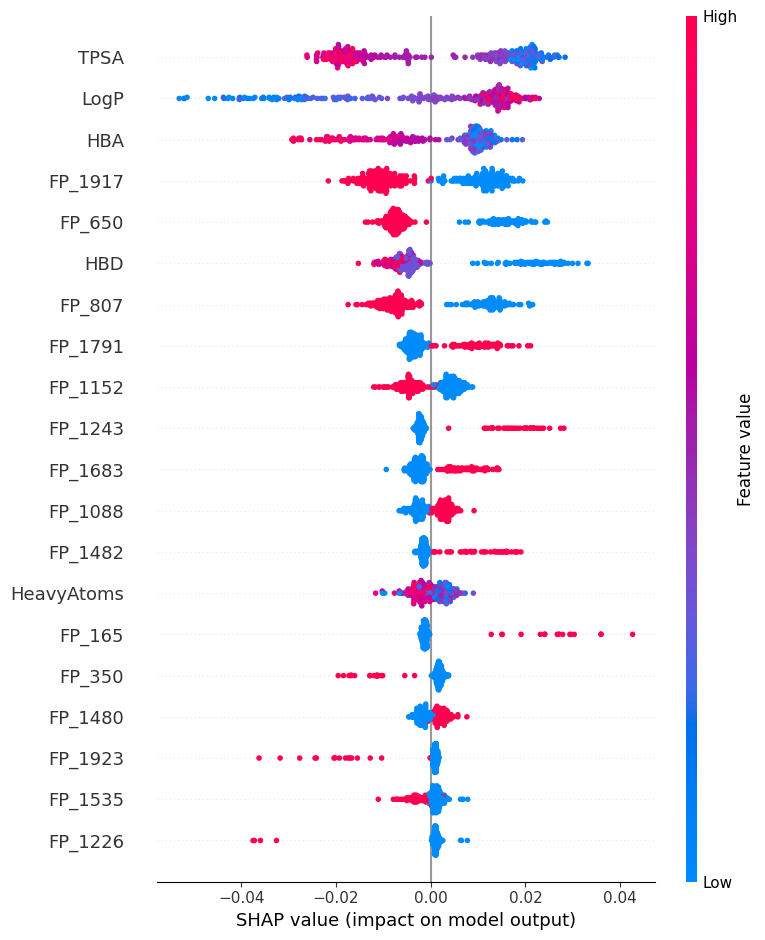

Saved shap_summary_plot.png


/tmp/ipykernel_22342/87648596.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_sample, feature_names=feature_names, plot_type="bar", max_display=20, show=False)


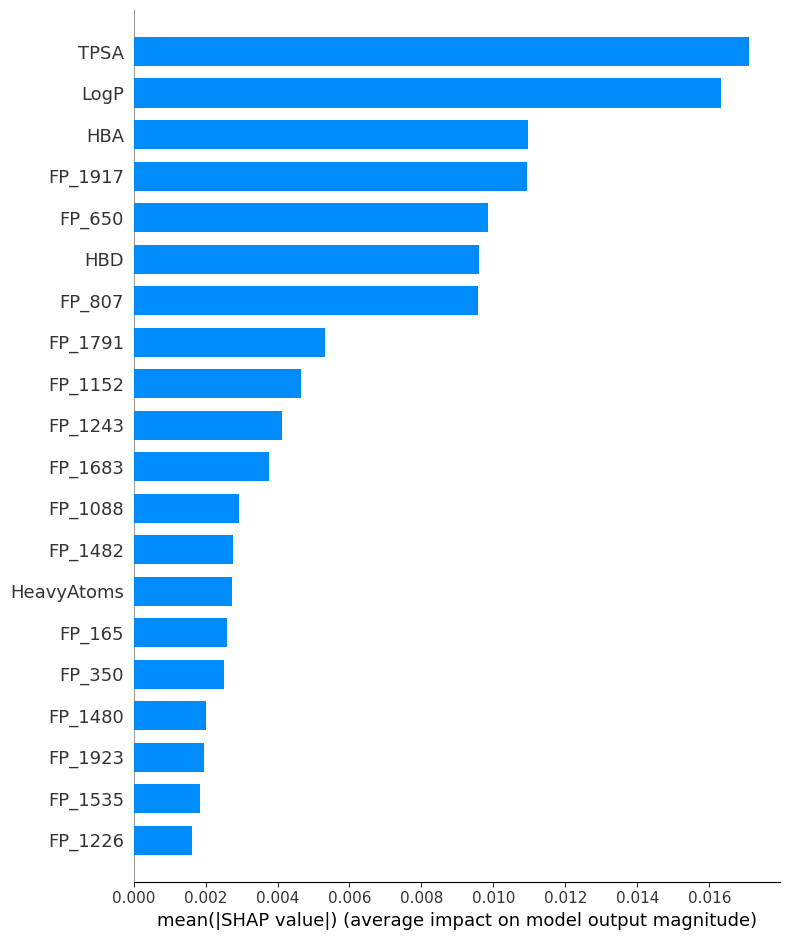

Saved shap_bar_plot.png

Top 15 features driving hERG blocker predictions:
  TPSA: 0.0171
  LogP: 0.0163
  HBA: 0.0110
  FP_1917: 0.0109
  FP_650: 0.0098
  HBD: 0.0096
  FP_807: 0.0096
  FP_1791: 0.0053
  FP_1152: 0.0047
  FP_1243: 0.0041
  FP_1683: 0.0038
  FP_1088: 0.0029
  FP_1482: 0.0028
  HeavyAtoms: 0.0027
  FP_165: 0.0026


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# shap_values shape is (300, 2056, 2) - select class 1 (blocker)
sv = shap_values[:, :, 1]

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_sample, feature_names=feature_names, max_display=20, show=False)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/shap_summary_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_summary_plot.png")

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_sample, feature_names=feature_names, plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/shap_bar_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_bar_plot.png")

mean_abs_shap = np.abs(sv).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:15]
print("\nTop 15 features driving hERG blocker predictions:")
for i in top_idx:
    print(f"  {feature_names[i]}: {mean_abs_shap[i]:.4f}")

In [4]:
!pip install -q --upgrade --force-reinstall numpy
!pip install -q --upgrade --force-reinstall pandas
!pip install -q --upgrade --force-reinstall --no-deps rdkit
!pip install -q --upgrade xgboost joblib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 43.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
libpysal 4.14.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
spopt 0.7.0 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
esda 2.9.0 requires scikit-learn>=1.4, but you have scikit-learn 1.2.2 which is incompatible.
mapclassify 2.10.0 requires scikit-learn>=1.4, but you have scikit-

In [1]:
import numpy as np
print("numpy:", np.__version__)
import pandas as pd
print("pandas OK:", pd.__version__)
import rdkit
print("RDKit OK:", rdkit.__version__)
import xgboost
print("xgboost OK:", xgboost.__version__)
import sklearn
print("sklearn OK:", sklearn.__version__)

numpy: 2.5.2
pandas OK: 3.0.5
RDKit OK: 2026.03.5
xgboost OK: 3.4.1
sklearn OK: 1.9.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/herg_hackathon'

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score)
import joblib

fp_matrix = np.load(f"{SAVE_DIR}/fp_matrix.npy")
meta = pd.read_csv(f"{SAVE_DIR}/herg_featurized_meta.csv")
desc = pd.read_csv(f"{SAVE_DIR}/descriptors.csv")

X = np.hstack([fp_matrix, desc.values])
y = meta["label"].values
train_mask = (meta["split"] == "train").values
test_mask = (meta["split"] == "test").values

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                     n_jobs=-1, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

probs = xgb.predict_proba(X_test)[:, 1]
preds = xgb.predict(X_test)

print("\nXGBoost")
print(f"  Accuracy:  {accuracy_score(y_test, preds):.4f}")
print(f"  Precision: {precision_score(y_test, preds):.4f}")
print(f"  Recall:    {recall_score(y_test, preds):.4f}")
print(f"  F1:        {f1_score(y_test, preds):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, probs):.4f}")
print(f"  PR-AUC:    {average_precision_score(y_test, probs):.4f}")

joblib.dump(xgb, f"{SAVE_DIR}/model_xgboost.pkl")
print("\nSaved model_xgboost.pkl")

Training XGBoost...

XGBoost
  Accuracy:  0.7680
  Precision: 0.7842
  Recall:    0.8184
  F1:        0.8009
  ROC-AUC:   0.8539
  PR-AUC:    0.8832

Saved model_xgboost.pkl
